In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
!pip install scikit-surprise
!pip install "numpy<2.0"
import numpy as np

In [ ]:
column_names = [
    "userId",
    "movieId",
    "categoryId",
    "reviewId",
    "rating",
    "reviewDate"
]

df = pd.read_csv(
    "movie-ratings.txt",
    sep=",",
    names=column_names,
    header=None
)

print("Original Shape:", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

df.to_csv("cleaned_ratings.csv", index=False)

print("\nCleaned dataset saved successfully.")

Original Shape: (72665, 6)
After Removing Duplicates: (72665, 6)

Missing Values:
userId        0
movieId       0
categoryId    0
reviewId      0
rating        0
reviewDate    0
dtype: int64

Cleaned dataset saved successfully.


##**Item-Based CF**

In [ ]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split, GridSearchCV
from surprise import KNNBasic, KNNWithMeans
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

print("Data loaded into Surprise format.")

Data loaded into Surprise format.


In [ ]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set size: {trainset.n_ratings}")
print(f"Test set size: {len(testset)}")

Training set size: 58132
Test set size: 14533


In [ ]:
param_grid_knn_basic = {
    'k': [20, 40, 60],
    'sim_options': {
        'name': ['msd', 'cosine', 'pearson'],
        'user_based': [False]  # Item-based similarity
    }
}
gs_knn_basic = GridSearchCV(KNNBasic, param_grid_knn_basic, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs_knn_basic.fit(data)

print("KNNBasic - Best RMSE score:", gs_knn_basic.best_score['rmse'])
print("KNNBasic - Best parameters:", gs_knn_basic.best_params['rmse'])

print("KNNBasic - Best MAE score:", gs_knn_basic.best_score['mae'])
print("KNNBasic - Best parameters:", gs_knn_basic.best_params['mae'])

KNNBasic - Best RMSE score: 1.0974505272716344
KNNBasic - Best parameters: {'k': 20, 'sim_options': {'name': 'msd', 'user_based': False}}
KNNBasic - Best MAE score: 0.8249788954908582
KNNBasic - Best parameters: {'k': 20, 'sim_options': {'name': 'msd', 'user_based': False}}


##**Global Average**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
df = pd.read_csv("cleaned_ratings.csv")

df = df[["userId", "movieId", "rating"]]

train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (58132, 3)
Test Shape: (14533, 3)


In [ ]:
global_avg = train["rating"].mean()

print("\nGlobal Average Rating:", round(global_avg, 3))

predictions = np.full(len(test), global_avg)

rmse = np.sqrt(mean_squared_error(test["rating"], predictions))
mae = mean_absolute_error(test["rating"], predictions)

print("\nBaseline Model Performance")
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))


Global Average Rating: 4.073

Baseline Model Performance
RMSE: 1.0821
MAE: 0.8351


##**Comparison**

In [ ]:
model_names = ['Global Average', 'Item-Based CF (KNNBasic)']
rmse_scores = [1.0821, 1.0974505272716344]
mae_scores = [0.8351, 0.8249788954908582]

performance_df = pd.DataFrame({
    'Model': model_names,
    'RMSE': rmse_scores,
    'MAE': mae_scores
})

print("\nModel Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,RMSE,MAE
0,Global Average,1.082100,0.835100
1,Item-Based CF (KNNBasic),1.097451,0.824979


/tmp/ipykernel_20139/1872755786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=performance_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_20139/1872755786.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=performance_df, ax=axes[1], palette='plasma')


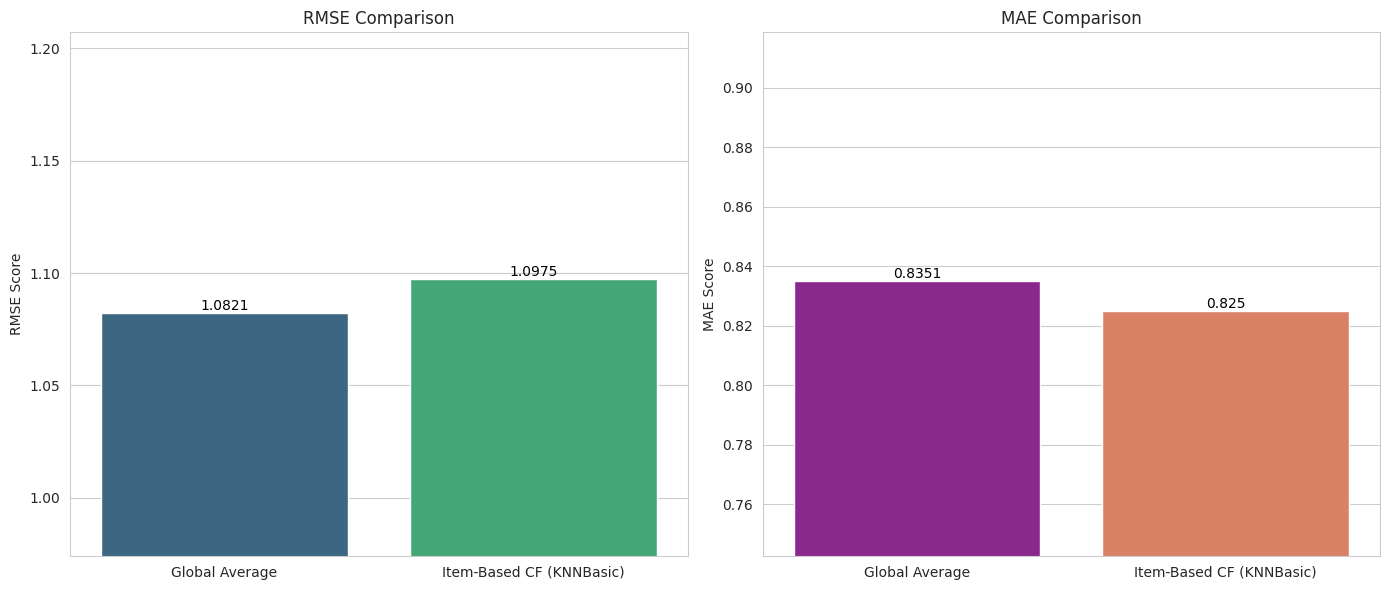

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(x='Model', y='RMSE', data=performance_df, ax=axes[0], palette='viridis')
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE Score')
axes[0].set_xlabel('')
axes[0].set_ylim(min(rmse_scores) * 0.9, max(rmse_scores) * 1.1)
for index, row in performance_df.iterrows():
    axes[0].text(row.name, row.RMSE, round(row.RMSE, 4), color='black', ha="center", va="bottom")


sns.barplot(x='Model', y='MAE', data=performance_df, ax=axes[1], palette='plasma')
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE Score')
axes[1].set_xlabel('')
axes[1].set_ylim(min(mae_scores) * 0.9, max(mae_scores) * 1.1)
for index, row in performance_df.iterrows():
    axes[1].text(row.name, row.MAE, round(row.MAE, 4), color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

##**Conclusion**
Both algorithms seemed to have very similar performances, with the global average having a higher MAE but a lower RMSE compared to item-based CF. This could be due to item-based CF not being complex enough to have a much higher score than global average. The sparsity of reviews making it harder for item-based CF to find similar items as well as the distribution of the ratings being greatly skewed to high ratings resulting in an imbalanced dataset.